# Classification in Python using pyjeo and sklearn

In [1]:
from IPython.display import display
import geopandas as gpd

ModuleNotFoundError: No module named 'geopandas'

In [2]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score

In [3]:
from datetime import datetime
import matplotlib.pyplot as plt
import numpy as np
import pyjeo as pj
import pandas as pd
import geopandas as gpd

ModuleNotFoundError: No module named 'pyjeo'

## Create reference data for training

In [4]:
# ! wget -P /media/sf_LVM_shared/my_SE_data/exercise https://github.com/ec-jrc/jeolib-pyjeo/blob/master/tests/data/modis_ndvi_2010.tif
# ! wget -P /media/sf_LVM_shared/my_SE_data/exercise https://github.com/ec-jrc/jeolib-pyjeo/blob/master/tests/data/modis_ndvi_training.sqlite


! curl -H 'Accept: application/vnd.github.v3.raw' -O -L 'https://github.com/ec-jrc/jeolib-pyjeo/raw/master/tests/data/modis_ndvi_training.sqlite'
! curl -H 'Accept: application/vnd.github.v3.raw' -O -L 'https://github.com/ec-jrc/jeolib-pyjeo/raw/master/tests/data/modis_ndvi_2010.tif'


!pwd


  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0

  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0

  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0


100 24576  100 24576    0     0  23433      0  0:00:01  0:00:01 --:--:-- 23433


  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0

  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0


  0     0    0     0    0     0      0      0 --:--:--  0:00:01 --:--:--     0

 14 3079k   14  431k    0     0   215k      0  0:00:14  0:00:02  0:00:12  452k

100 3079k  100 3079k    0     0  1028k      0  0:00:02  0:00:02 --:--:-- 1588k


/home/selv/SE_docs/SE_docs/source/CASESTUDY


In [5]:
reference = pj.JimVect('modis_ndvi_training.sqlite')
jim = pj.Jim('modis_ndvi_2010.tif', band2plane=True)

NameError: name 'pj' is not defined

In [6]:
dates = [datetime.strptime('01-' + str(month) + '-2010', "%d-%m-%Y") for month in range(1, 13)]
jim.properties.setDimension({'band': ['NDVI'], 'plane': dates})

NameError: name 'jim' is not defined

In [7]:
jim.xr()

NameError: name 'jim' is not defined

In [8]:
jim.xr().NDVI.plot(col='time', col_wrap=6)

NameError: name 'jim' is not defined

In [9]:
pd.DataFrame(reference.dict())

NameError: name 'pd' is not defined

In [10]:
featurevect = pj.geometry.extract(reference, jim, rule=['allpoints'],
                                  output='/vsimem/features.sqlite',
                                  oformat='SQLite',
                                  co=['OVERWRITE=YES'],
                                  classes=[1, 2],
                                  copy='label')
gdf = gpd.read_file('/vsimem/features.sqlite')
gdf

NameError: name 'pj' is not defined

NameError: name 'jim' is not defined

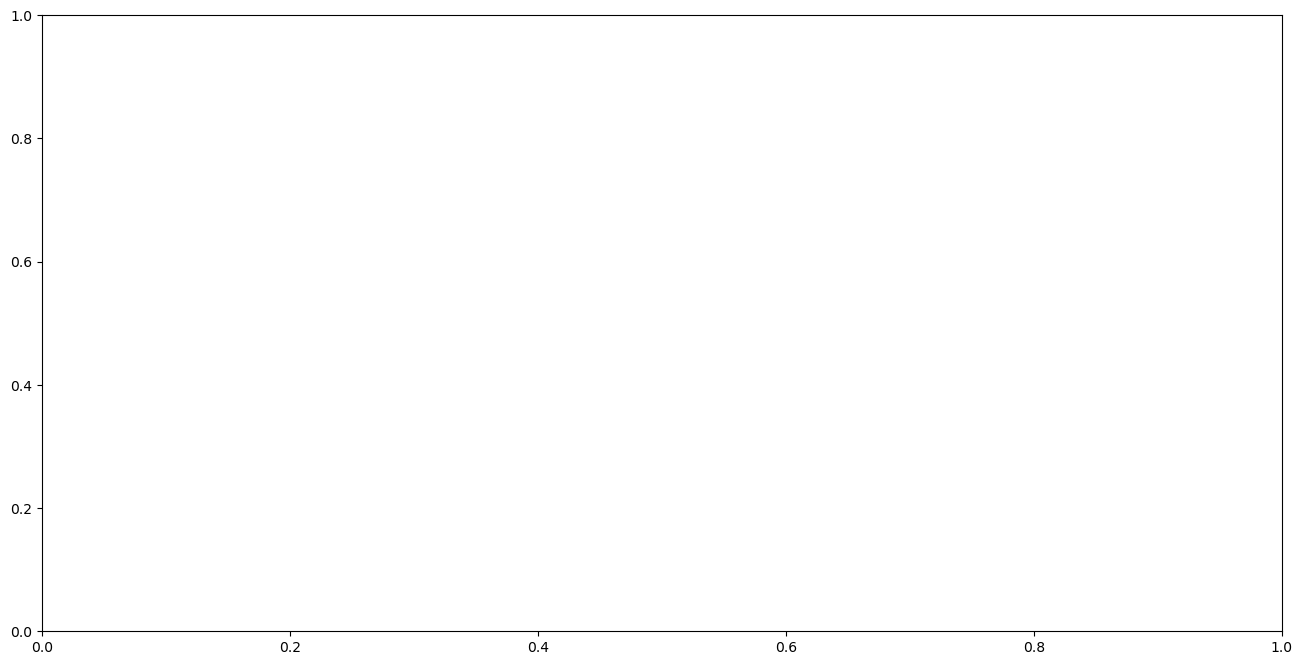

In [11]:
plt.figure(figsize=(16, 8))
ax = plt.subplot()
jim.xr().NDVI.isel(time = 0).plot(ax = ax)
gdf.plot(column = 'label', ax = ax, legend = True, categorical=True, cmap='Set1')

In [12]:
pd.DataFrame(featurevect.dict())

NameError: name 'pd' is not defined

## Train the model

In [13]:
x = featurevect.np()[:, 1:]
y = featurevect.np()[:, 0:1]
x_train, x_test, y_train, y_test = train_test_split(x, y,
                                                    test_size=0.33,
                                                    random_state=42)
rfModel = RandomForestClassifier(n_estimators=100,
                                 max_depth=9,
                                 min_samples_leaf=5,
                                 min_samples_split=3,
                                 criterion='gini')
rfModel.fit(x_train, y_train.ravel())

NameError: name 'featurevect' is not defined

In [14]:
y_predict = rfModel.predict(x_test)
print(confusion_matrix(y_test, y_predict))
print('accuracy score: {}'.format(accuracy_score(y_test, y_predict)))

NameError: name 'rfModel' is not defined

## Prediction

In [15]:
x = jim.np()
x = x.reshape(jim.properties.nrOfPlane(), jim.properties.nrOfRow() * \
                      jim.properties.nrOfCol()).T

jim_class = pj.Jim(ncol=jim.properties.nrOfCol(),
                   nrow=jim.properties.nrOfRow(),
                   otype='Byte')
jim_class.properties.copyGeoReference(jim)
jim_class.np()[:] = rfModel.predict(x).astype(np.dtype(np.uint8)).\
            reshape(jim.properties.nrOfRow(), jim.properties.nrOfCol())
jim_class.properties.setDimension(['water'], 'band')

NameError: name 'jim' is not defined

NameError: name 'jim' is not defined

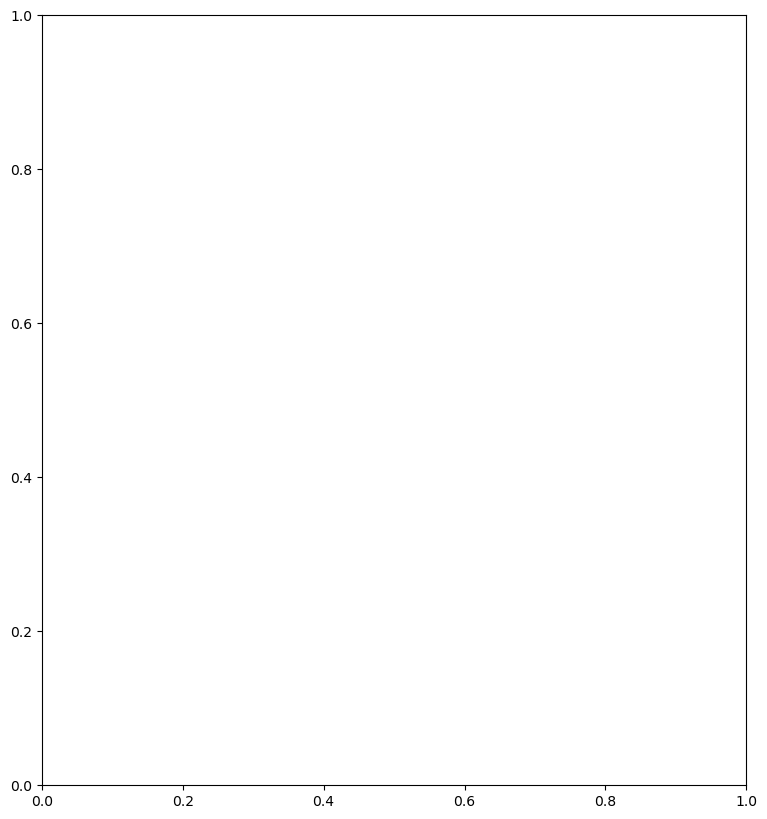

In [16]:
plt.figure(figsize=(20, 10))
ax1 = plt.subplot(121)
jim.xr().NDVI.isel(time = 0).plot(ax = ax1)
ax2 = plt.subplot(122)
jim_class.xr().water.plot(cmap = 'Set2', levels = [1, 2], ax = ax2)

## Exercise 1
Use a single feature to train the classifier (e.g., month of June only)  
Check the accuracy

What is the accuracy?

## Exercise 2
Replace the Random Forest with a Support Vector Machine
(hint: use the `preprocessing.MinMaxScaler` to scale the input data)

In [17]:
from sklearn.svm import SVC
from sklearn import preprocessing

What is the accuracy?

In [18]:
y_predict = svmModel.predict(preprocessing.MinMaxScaler().fit_transform(x_test))
print(confusion_matrix(y_test, y_predict))
print('accuracy score: {}'.format(accuracy_score(y_test, y_predict)))

NameError: name 'svmModel' is not defined

Prediction

In [19]:
x = jim.np()
x = x.reshape(jim.properties.nrOfPlane(), jim.properties.nrOfRow() * \
              jim.properties.nrOfCol()).T


jim_class = pj.Jim(ncol=jim.properties.nrOfCol(),
                   nrow=jim.properties.nrOfRow(), otype='Byte')
jim_class.properties.copyGeoReference(jim)
jim_class.np()[:] = 
jim_class.properties.setDimension(['water'], 'band')

SyntaxError: invalid syntax (1575042382.py, line 9)

Plot

NameError: name 'jim' is not defined

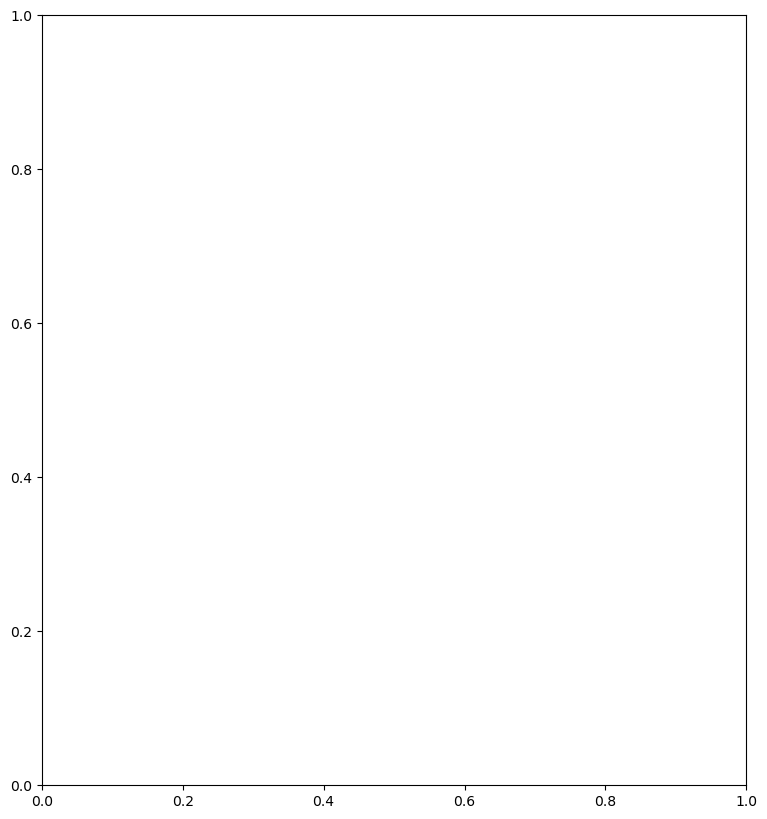

In [20]:
plt.figure(figsize=(20, 10))
ax1 = plt.subplot(121)
jim.xr().NDVI.isel(time = 0).plot(ax = ax1)
ax2 = plt.subplot(122)
jim_class.xr().water.plot(cmap = 'Set2', levels = [1, 2], ax = ax2)